In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
df= pd.read_csv('/content/ToyotaCorolla - MLR.csv')

In [96]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [97]:
df.shape

(1436, 11)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [99]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [100]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

NUll

In [101]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [102]:
df.duplicated().sum()

np.int64(1)

In [103]:
df = df.drop_duplicates()

In [104]:
df.duplicated().sum()

np.int64(0)

In [105]:
df = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)

In [106]:
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [107]:
df.dtypes

,0
Price,int64
Age_08_04,int64
KM,int64
HP,int64
Automatic,int64
cc,int64
Doors,int64
Cylinders,int64
Gears,int64
Weight,int64


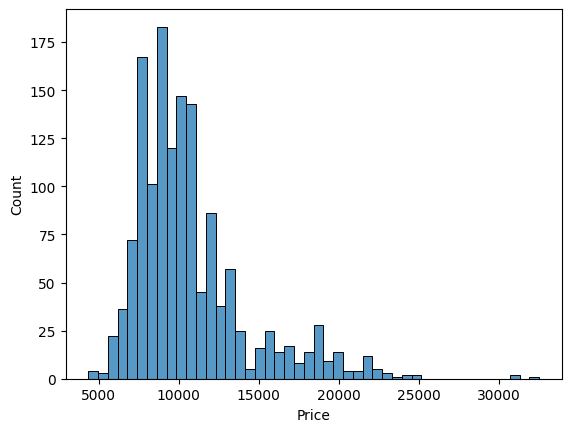

In [108]:
sns.histplot(df['Price'])
plt.show()

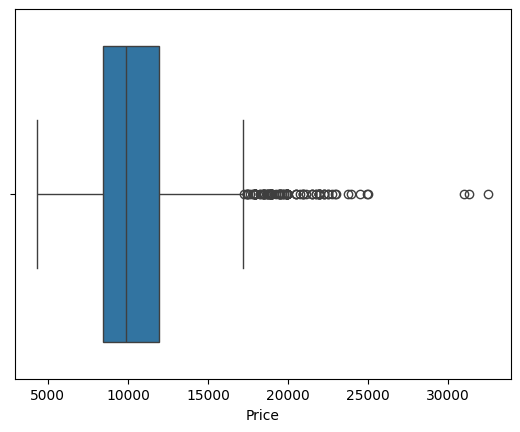

In [109]:
sns.boxplot(x=df['Price'])
plt.show()

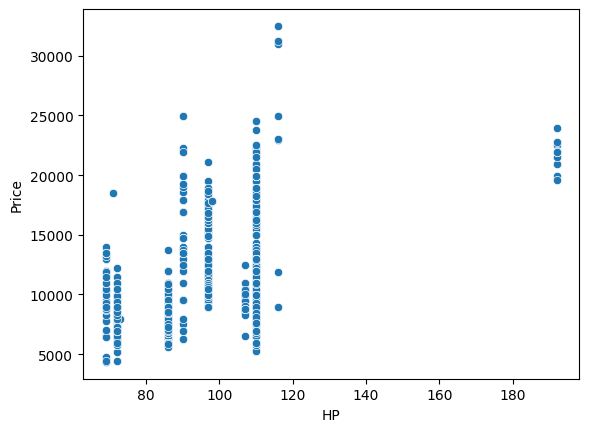

In [110]:
sns.scatterplot(x=df['HP'], y=df['Price'])
plt.show()

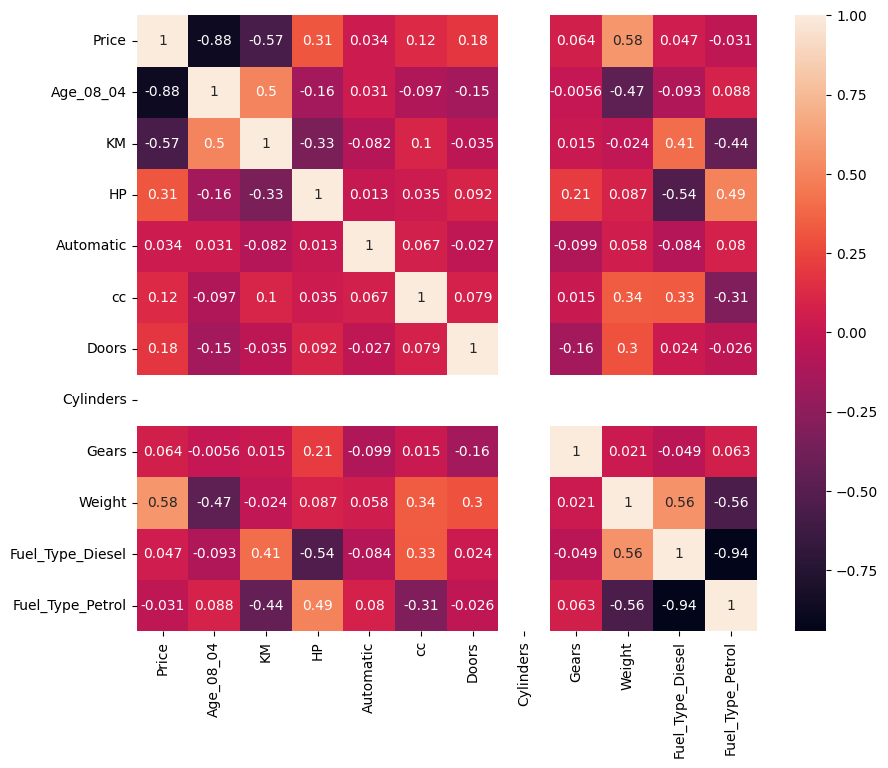

In [111]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [112]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol'],
      dtype='object')

In [113]:
y =  df["Price"]

In [114]:
X = df[["Age_08_04", "KM", "HP", "Weight"]]

In [115]:
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()

In [ ]:
model1.fit(X,y)
y_pred = model1.predict(X)

In [ ]:
model1.coef_

array([-1.22470468e+02, -1.95805878e-02,  3.02027421e+01,  1.83840386e+01])

In [ ]:
model1.intercept_

np.float64(-3858.7558842255403)

In [ ]:
print("Actual Price:", y.iloc[0])
print("Predicted Price:", y_pred[0])

Actual Price: 13500
Predicted Price: 16540.06165369138


In [ ]:
from sklearn.metrics import r2_score
r2_score(y,y_pred)

0.8605512516617329

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y, y_pred)

print("MAE:", mae)

MAE: 997.4918247371058


In [154]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test3, y_pred3)
print("MAE:", mae)

MAE: 1097.339272676412


In [155]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test3, y_pred3)

rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 2205322.17215939
RMSE: 1485.032717538368


**2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).**

In [125]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models**

In [126]:
y_pred=['HP']

In [127]:
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)

In [128]:
from sklearn.model_selection import train_test_split
X_model2 = df[["Age_08_04","HP"]]
y_model2 = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(X_model2, y_model2, test_size=0.2, random_state=42)

In [129]:
from sklearn.linear_model import LinearRegression
model2 = LinearRegression()
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)

In [130]:
from sklearn.model_selection import train_test_split
X_model3 = df[["Age_08_04","HP","Weight"]]
y_model3 = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(X_model3, y_model3, test_size=0.2, random_state=42)

In [131]:
from sklearn.linear_model import LinearRegression
model3 = LinearRegression()
model3.fit(X_train, y_train)
y_pred = model3.predict(X_test)

In [132]:
model1.coef_
model1.intercept_

np.float64(-5626.020126524485)

In [133]:
model2.coef_
model2.intercept_

np.float64(15295.585808860178)

In [134]:
model3.coef_
model3.intercept_

np.float64(-2601.6161843622904)

**4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.**

In [135]:
from sklearn.metrics import mean_absolute_error
mea = mean_absolute_error(y_test, y_pred)
print("MEA:", mea)

MEA: 1097.339272676412


In [136]:

from sklearn .metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 2205322.17215939


In [137]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8161792463011638

In [138]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 1499.171769789226


In [139]:
X_model1 = df[["Weight"]]
y_model1 = df["Price"]

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_model1, y_model1, test_size=0.2, random_state=42
)

model1 = LinearRegression()
model1.fit(X_train1, y_train1)

y_pred1 = model1.predict(X_test1)

In [140]:
X_model2 = df[["Age_08_04", "HP"]]
y_model2 = df["Price"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_model2, y_model2, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

In [141]:
X_model3 = df[["Age_08_04", "HP", "Weight"]]
y_model3 = df["Price"]

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_model3, y_model3, test_size=0.2, random_state=42
)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

In [142]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [156]:
mae1 = mean_absolute_error(y_test1, y_pred1)
mse1 = mean_squared_error(y_test1, y_pred1)
rmse1 = np.sqrt(mse1)
r2_1 = r2_score(y_test1, y_pred1)

print("Model 1")
print("MAE:", mae1)
print("MSE:", mse1)
print("RMSE:", rmse1)
print("R2:", r2_1)

Model 1
MAE: 2168.2786696637068
MSE: 8741235.755318634
RMSE: 2956.5580926676603
R2: 0.2713896567645109


In [157]:
mae2 = mean_absolute_error(y_test2, y_pred2)
mse2 = mean_squared_error(y_test2, y_pred2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(y_test2, y_pred2)

print("Model 2")
print("MAE:", mae2)
print("MSE:", mse2)
print("RMSE:", rmse2)
print("R2:", r2_2)

Model 2
MAE: 1166.3040441831752
MSE: 2489746.6681302697
RMSE: 1577.8931104895128
R2: 0.7924715423294649


In [158]:
mae3 = mean_absolute_error(y_test3, y_pred3)
mse3 = mean_squared_error(y_test3, y_pred3)
rmse3 = np.sqrt(mse3)
r2_3 = r2_score(y_test3, y_pred3)

print("Model 3")
print("MAE:", mae3)
print("MSE:", mse3)
print("RMSE:", rmse3)
print("R2:", r2_3)

Model 3
MAE: 1097.339272676412
MSE: 2205322.17215939
RMSE: 1485.032717538368
R2: 0.8161792463011638


In [146]:
from sklearn.linear_model import Lasso, Ridge

In [147]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train3, y_train3)

y_pred_lasso = lasso.predict(X_test3)

In [148]:

mae_lasso = mean_absolute_error(y_test3, y_pred_lasso)
mse_lasso = mean_squared_error(y_test3, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test3, y_pred_lasso)

print("LASSO")
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2  :", r2_lasso)

LASSO
MAE : 1097.338360899378
MSE : 2205318.314540912
RMSE: 1485.0314187049753
R2  : 0.8161795678461721


In [149]:
Ridge = Ridge(alpha=0.1)
Ridge.fit(X_train3, y_train3)
y_pred_Ridge = Ridge.predict(X_test3)

In [150]:
mae_lasso = mean_absolute_error(y_test3, y_pred_lasso)
mse_lasso = mean_squared_error(y_test3, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test3, y_pred_lasso)

print("LASSO")
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2  :", r2_lasso)

LASSO
MAE : 1097.338360899378
MSE : 2205318.314540912
RMSE: 1485.0314187049753
R2  : 0.8161795678461721


In [151]:
final_comparison = pd.DataFrame({
    "Model": [
        "MLR Model 1",
        "MLR Model 2",
        "MLR Model 3",
        "Lasso",
        "Ridge"
    ],

    "MAE": [
        mae1,
        mae2,
        mae3,
        mae_lasso,
        mae_ridge
    ],

    "MSE": [
        mse1,
        mse2,
        mse3,
        mse_lasso,
        mse_ridge
    ],

    "RMSE": [
        rmse1,
        rmse2,
        rmse3,
        rmse_lasso,
        rmse_ridge
    ],

    "R2": [
        r2_1,
        r2_2,
        r2_3,
        r2_lasso,
        r2_ridge
    ]
})

final_comparison

,Model,MAE,MSE,RMSE,R2
0,MLR Model 1,2168.278670,8.741236e+06,2956.558093,0.271390
1,MLR Model 2,1166.304044,2.489747e+06,1577.893110,0.792472
2,MLR Model 3,1097.339273,2.205322e+06,1485.032718,0.816179
3,Lasso,1097.338361,2.205318e+06,1485.031419,0.816180
4,Ridge,1093.255249,2.247516e+06,1499.171834,0.831556


Normalization

Normalization is a technique used to scale numerical values into a fixed range, usually 0 to 1.
Normalization

Standardization

 Standardization transforms the data so that it has a mean of 0 and standard deviation of 1.



Remove highly correlated features
Remove one of the variables when two predictors contain very similar information.

Correlation Matrix
Use a correlation matrix to identify highly correlated independent variables.

VIF (Variance Inflation Factor)
VIF can be used to detect multicollinearity. A high VIF indicates a possible multicollinearity problem.

Lasso Regression
Lasso can reduce some coefficients to exactly zero, helping with feature selection.

Ridge Regression
Ridge shrinks coefficients toward zero and is useful when predictors are highly correlated.

Principal Component Analysis (PCA)
PCA can transform correlated variables into a smaller set of uncorrelated components.

In [152]:

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np


mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)


mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

r2 = r2_score(y_test, y_pred)
print("R2:", r2)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

MAE: 1097.339272676412
MSE: 2205322.17215939
R2: 0.8161792463011638
RMSE: 1485.032717538368
